In [81]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Importation of our class from other files 

In [82]:
from Main_functions import Data_exploitation
from Main_functions import SimulationParaxiale
from Extraction_data import Extracted_data
from Multipolar_decomposition import Decomposition
from Fit_functions import Fit_constants
from paraxial import Ion
import numpy as np

#files with our potential data
file_pathz = r"C:\Users\zoeno\OneDrive - INSA Toulouse\Documents\INSA\4GP\Projet multi\projet-multi-code\Quadrupole_model\Files\potentiel_quadrupole_VF.npz"

file_pathl = r"C:\Users\llamm\OneDrive\Documents\Projet\BEMPP\okayama\projet_multi\projet-multi-code\Quadrupole_model\Files\potentiel_quadrupole_VF.npz"



In [83]:
extracted_data = Extracted_data(file_pathl) 
extracted_data.derivative()
fit_constants = Fit_constants(0.80751, 5.08, 2.54, 0.03891461, 3.113, 2.015, 2.4, 3.493e-3, extracted_data)
fun = Data_exploitation(extracted_data, fit_constants)
Decomp= Decomposition(extracted_data)
Decomp.composantes()

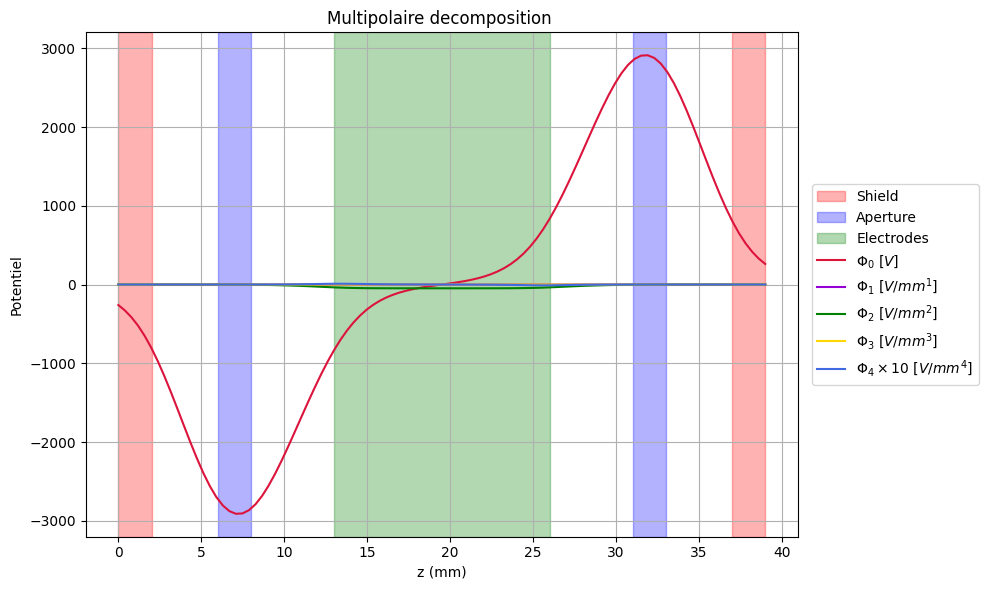

In [84]:
fun.decomposition_calculation()
fun.decomposition_graph()

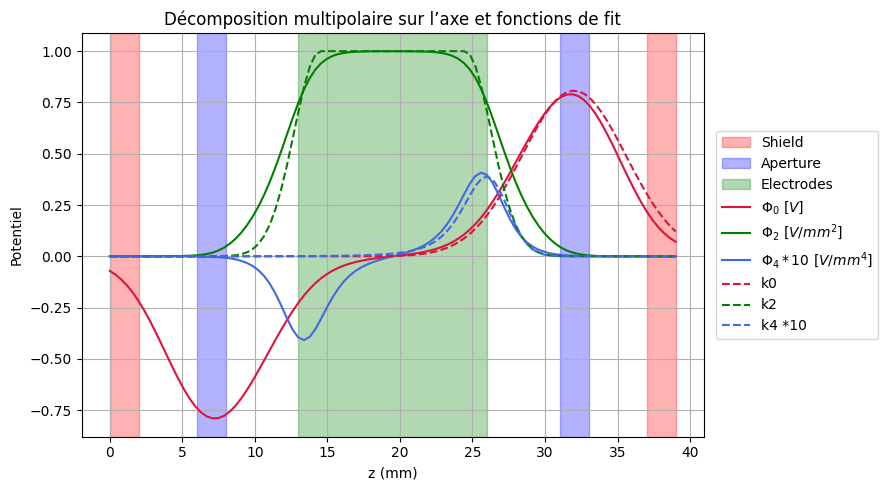

In [85]:
fun.fit_calculation()
fun.fit_graph()

Trajectoire Paraxiale

20000
20000


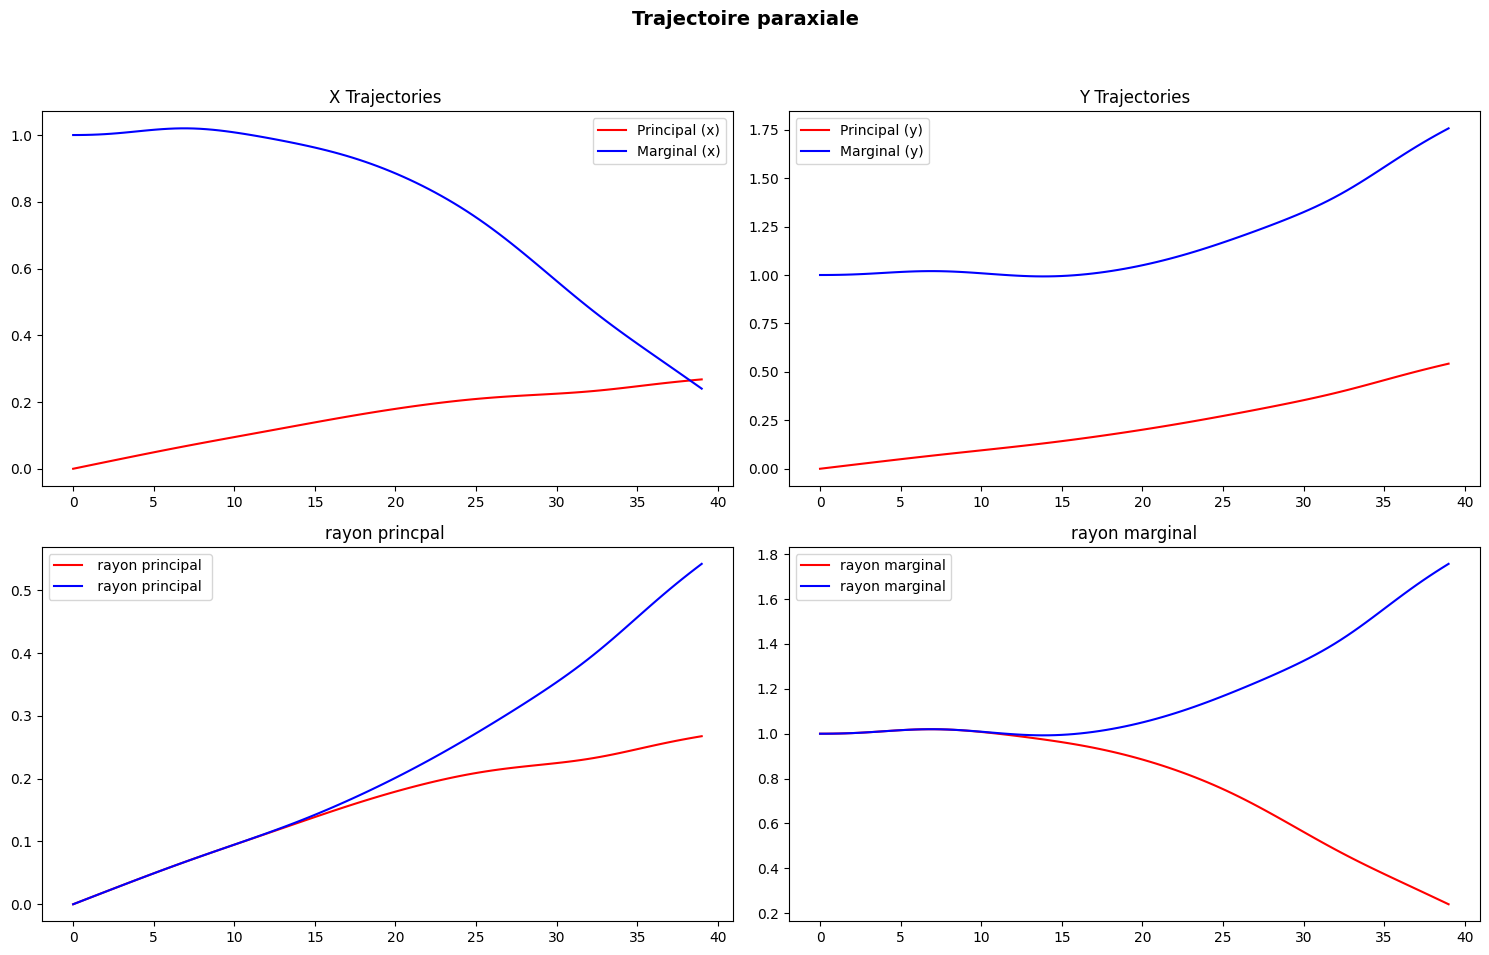

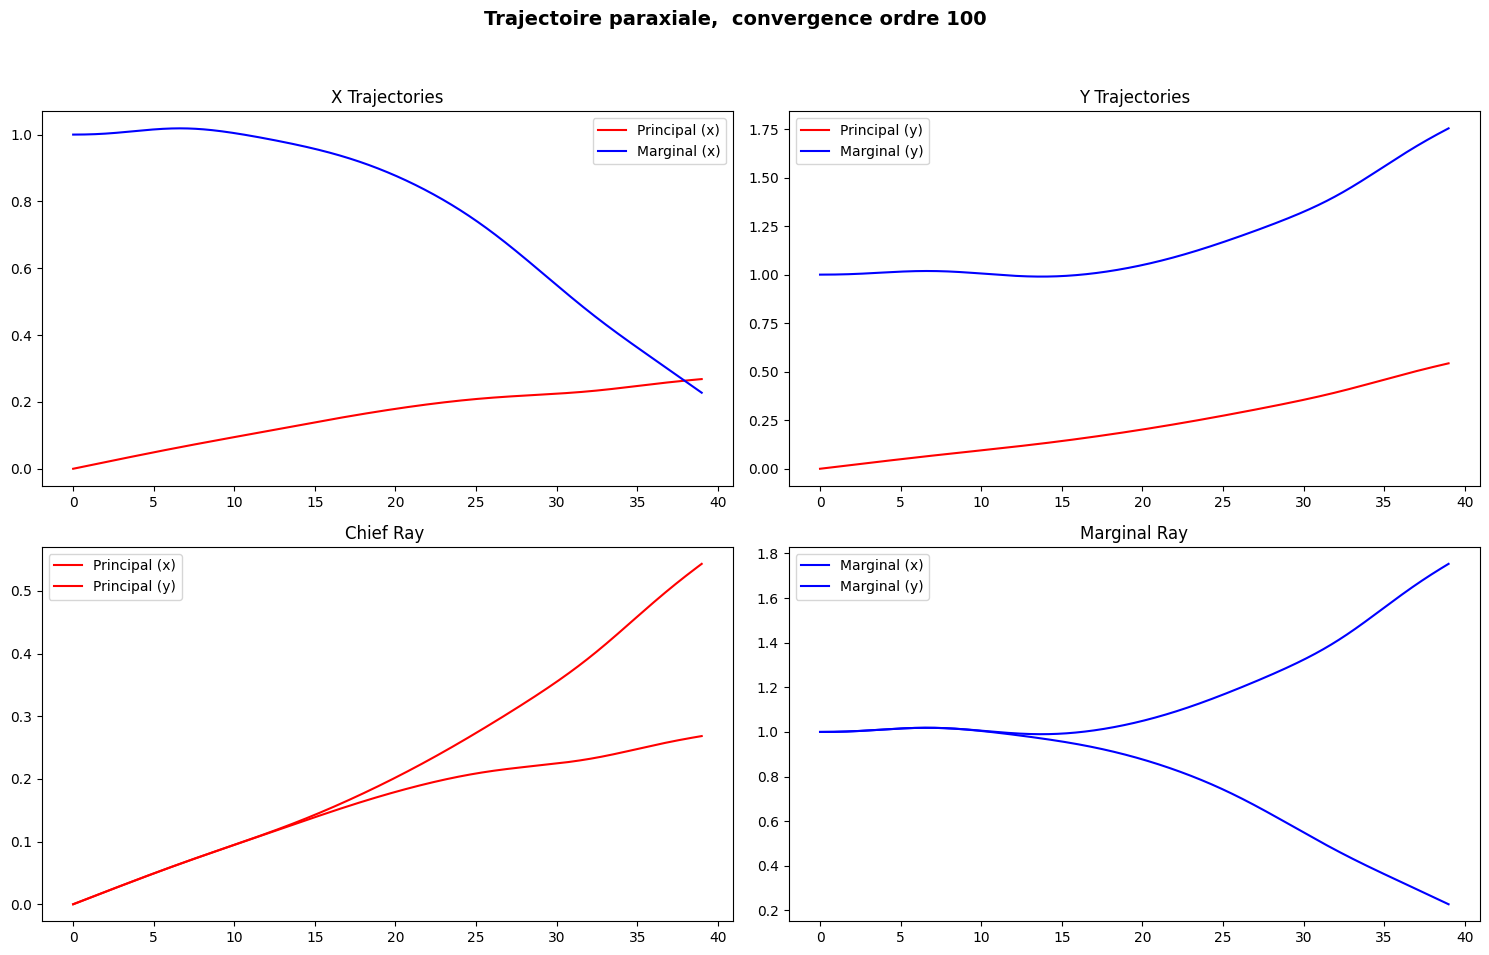

In [86]:
n = 100
e = -1.6e-19

marginal = Ion(1.6e-27, e, "principal", 0, 0.01, 0, 0.01)
principal = Ion(1.6e-27, e, "marginal", 1, 0, 1, 0)

marginalc = Ion(1.6e-27, e, "marginal", 0, 0.01, 0, 0.01)
principalc = Ion(1.6e-27, e, "principal", 1, 0, 1, 0)

Trajectoire = SimulationParaxiale(extracted_data, Decomp)
Trajectoire.run_discret(marginal, principal)

Trajectoire.run_convergence(marginalc, principalc, n)


20000
20000
20000
20000
20000


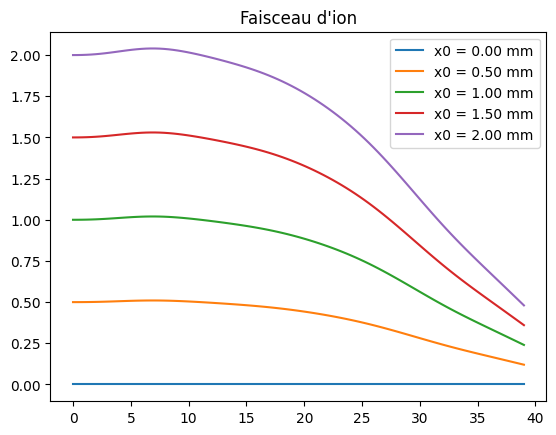

In [87]:

#faisceau
liste = []

#n nombre d'ion que l'on veut 
nb = 5

positions_initiales = np.linspace(0, 2, nb)
for i in positions_initiales:
    ion= Ion(1.6e-27, e, f"Ion_{i:.1f}", i, 0.00, i, 0.00)
    liste.append(ion)


Trajectoire.run_faisceau(liste)